In [3]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.layers import SimpleRNN, Dense, Dropout, LSTM, GRU
from tensorflow import keras
from sklearn.metrics import accuracy_score, matthews_corrcoef, precision_score, recall_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
neg=pd.read_csv('/content/drive/MyDrive/Thesis/Neg Dataset.csv')
pos=pd.read_csv('/content/drive/MyDrive/Thesis/Pos Dataset.csv')
#random_records = neg.sample(n=6000, random_state=42)
#df = pd.concat([random_records, pos], ignore_index=True)
df = pd.concat([pos, neg], ignore_index=True)

In [6]:
df

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C145,C146,C147,C148,C149,C150,C151,C152,C153,class
0,35141,1047051,41527343,1856306445,1046158,31159371,1233964119,41110980,1225020277,1814866984,...,243810,114721,346611,374615,394713,453238,141629,138537,0,1
1,2685,22196,240762,2951180,22101,179386,1923320,235939,1876790,2841159,...,1579,2152,1300,2485,1754,2270,1111,677,0,1
2,824,4154,26092,183302,4206,21176,132266,26432,131618,183630,...,135,2,370,319,88,30,40,0,0,1
3,8842,136558,2762124,62896558,130662,2012908,40731716,2534428,38933692,55378950,...,22487,19351,13697,32217,19893,20120,3062,12924,0,1
4,7504,107289,1967601,40342947,107090,1531399,28020981,1978172,28239377,40913240,...,24298,11033,10797,26283,10130,14104,3009,3225,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11345,566,2541,14347,90861,1994,8915,50871,8764,38627,43568,...,81,0,0,84,113,17,47,91,0,0
11346,718,3219,18453,118773,2864,12298,68826,14594,59892,84698,...,103,0,66,115,363,47,0,93,0,0
11347,1237,7014,49602,391356,6536,36808,258562,43412,239936,324218,...,82,0,55,262,307,28,187,827,0,0
11348,638,2759,15015,92063,2499,10456,55706,12047,48916,65031,...,103,0,112,14,242,69,0,106,0,0


In [7]:
X=df.drop(['class'],axis=1)
y=df['class']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

In [9]:
std_scale = MinMaxScaler().fit(X)
X = std_scale.fit_transform(X)

In [10]:
X

array([[3.79460711e-01, 2.35561778e-01, 1.46935093e-01, ...,
        4.88969370e-01, 1.70067727e-01, 0.00000000e+00],
       [2.82737129e-02, 4.95547431e-03, 8.49992719e-04, ...,
        3.83569022e-03, 8.31083760e-04, 0.00000000e+00],
       [8.13694302e-03, 8.95779105e-04, 9.04217460e-05, ...,
        1.38098658e-04, 0.00000000e+00, 0.00000000e+00],
       ...,
       [1.26057694e-02, 1.53931797e-03, 1.73607629e-04, ...,
        6.45611225e-04, 1.01522344e-03, 0.00000000e+00],
       [6.12434807e-03, 5.81885146e-04, 5.12277847e-05, ...,
        0.00000000e+00, 1.30125375e-04, 0.00000000e+00],
       [1.62306044e-02, 2.33384096e-03, 3.13756913e-04, ...,
        3.86676242e-04, 1.78615491e-03, 0.00000000e+00]])

In [11]:
# y_test

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)



input_dim=153
num_classes=2
# Reshape input dataone hot enciding to pandas series
X_train = X_train.reshape(-1, input_dim)
X_test = X_test.reshape(-1, input_dim)

# # Convert output data to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

In [13]:
X_train.shape

(9080, 153)

In [14]:
print(X_train.shape)  # Should be (number_of_samples, input_dim)
print(X_test.shape)   # Should be (number_of_samples, input_dim)


(9080, 153)
(2270, 153)


In [15]:

# Adding a dropout layer to handle overfitting
# Define the FCN model architecture with multiple hidden layers
fcn_model = Sequential()
fcn_model.add(Dense(128, input_shape=(input_dim, ), activation='relu'))
fcn_model.add(Dense(64, activation='relu'))
fcn_model.add(Dense(32, activation='relu'))
fcn_model.add(Dense(16, activation='relu'))
fcn_model.add(Dense(8, activation='relu'))
fcn_model.add(Dense(num_classes, activation='softmax'))  # Output layer changed for 2 classes
# Compile the model
fcn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
fcn_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.7649 - loss: 0.4827 - val_accuracy: 0.9172 - val_loss: 0.2275
Epoch 2/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.9308 - loss: 0.2088 - val_accuracy: 0.9211 - val_loss: 0.2109
Epoch 3/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9365 - loss: 0.1935 - val_accuracy: 0.9251 - val_loss: 0.1917
Epoch 4/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9385 - loss: 0.1882 - val_accuracy: 0.9577 - val_loss: 0.1545
Epoch 5/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9463 - loss: 0.1734 - val_accuracy: 0.9286 - val_loss: 0.1867
Epoch 6/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9412 - loss: 0.1758 - val_accuracy: 0.9511 - val_loss: 0.1626
Epoch 7/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9459 - loss: 0.1715 - val_accuracy: 0.9326 - val_loss: 0.1961
Epoch 8/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9408 - loss: 0.1828 - val_a

In [17]:
fcn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          19,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │              18 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 92,192 (360.13 KB)

 Trainable params: 30,730 (120.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,462 (240.09 KB)

Dense Layer 1 = (153 + 1) * 264 = 154 * 264 = 40656 <br>
Dense Layer 2 = (264 + 1) * 128 = 265 * 128 = 33920 <br>
Dense Layer 3 = (128 + 1) * 64 = 129 * 64 = 8256 <br>
Dense Layer 3 = (64 + 1) * 2 = 65 * 2 = 130


In [18]:
# Get the predictions from the best model
y_test_pred = fcn_model.predict(X_test)

# Convert the predictions to binary labels
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

# Convert the true labels to binary labels
y_test_true_labels = np.argmax(y_test, axis=1)

# Calculate accuracy
test_accuracy = accuracy_score(y_test_true_labels, y_test_pred_labels)

# Calculate MCC
test_mcc = matthews_corrcoef(y_test_true_labels, y_test_pred_labels)

# Calculate specificity
test_specificity = recall_score(y_test_true_labels, y_test_pred_labels, pos_label=0)

# Calculate sensitivity
test_sensitivity = recall_score(y_test_true_labels, y_test_pred_labels, pos_label=1)
print("FCN")
print("Test Accuracy:", test_accuracy)
print("Test MCC:", test_mcc)
print("Test Specificity:", test_specificity)
print("Test Sensitivity:", test_sensitivity)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
FCN
Test Accuracy: 0.9555066079295155
Test MCC: 0.9018077531046077
Test Specificity: 0.9803389830508474
Test Sensitivity: 0.909433962264151


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


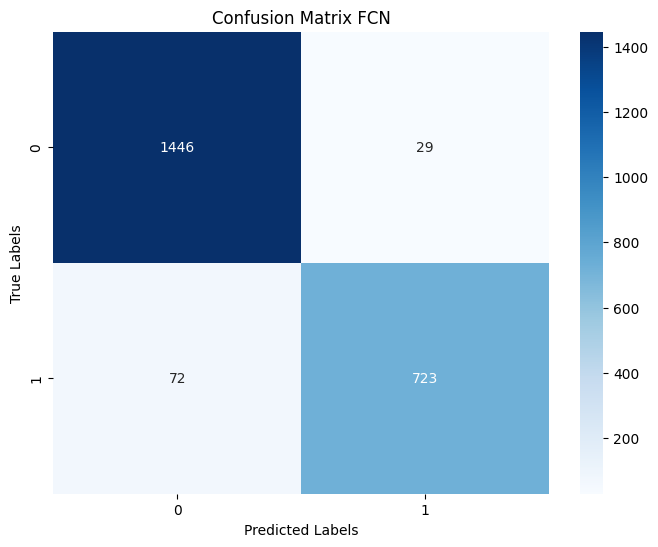

In [19]:

# Assuming your model is already trained and you have test data X_test, y_test

# Predict classes using the trained model
y_pred = np.argmax(fcn_model.predict(X_test), axis=1)

# Calculate confusion matrix
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix FCN')
plt.show()


In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Use predict to get probabilities for Keras models
probs_fcn = fcn_model.predict(X_test)

# For binary classification, select the probability of the positive class
fcn_proba = probs_fcn[:, 1]

# Assuming y_test is in multilabel-indicator format, convert to binary format
y_test_binary = np.argmax(y_test, axis=1)  # Get the index of the true class for each sample

fcn_fpr, fcn_tpr, thresholds = roc_curve(y_test_binary,fcn_proba )
fcn_roc_auc = roc_auc_score(y_test_binary, fcn_proba)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


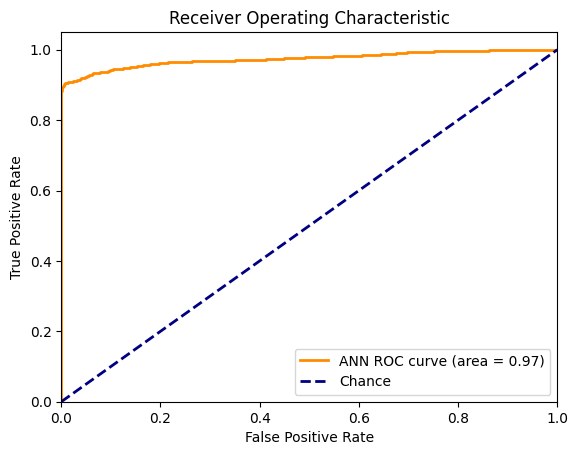

In [21]:
plt.figure()

plt.plot(fcn_fpr, fcn_tpr, color='darkorange', lw=2, label='ANN ROC curve (area = %0.2f)' % fcn_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2,label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [22]:
cnn = Sequential()

# Adding the first convolutional layer with 64 filters, kernel size 3, and ReLU activation function
cnn.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(input_dim,1)))

# Adding a max pooling layer
cnn.add(MaxPooling1D(pool_size=2))

# Adding the second convolutional layer with 32 filters, kernel size 3, and ReLU activation function
cnn.add(Conv1D(32, kernel_size=3, activation='relu'))

# Adding a max pooling layer
cnn.add(MaxPooling1D(pool_size=2))

# Adding the third convolutional layer with 16 filters, kernel size 3, and ReLU activation function
cnn.add(Conv1D(16, kernel_size=3, activation='relu'))

# Adding a max pooling layer
cnn.add(MaxPooling1D(pool_size=2))

# Flattening the output of the convolutional layers
cnn.add(Flatten())

# Adding a fully connected layer with 128 neurons and ReLU activation function
cnn.add(Dense(128, activation='relu'))

# Adding a dropout layer to handle overfitting
cnn.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding a fully connected layer with 64 neurons and ReLU activation function
cnn.add(Dense(64, activation='relu'))

# Adding a dropout layer to handle overfitting
cnn.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding the output layer with appropriate activation function (e.g., softmax for classification)
cnn.add(Dense(num_classes, activation='softmax'))

# Compile the model
cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
cnn.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7292 - loss: 0.5410 - val_accuracy: 0.9189 - val_loss: 0.2280
Epoch 2/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9195 - loss: 0.2391 - val_accuracy: 0.9278 - val_loss: 0.2013
Epoch 3/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9359 - loss: 0.2005 - val_accuracy: 0.9454 - val_loss: 0.1783
Epoch 4/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9363 - loss: 0.1946 - val_accuracy: 0.9467 - val_loss: 0.1654
Epoch 5/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9339 - loss: 0.2008 - val_accuracy: 0.9273 - val_loss: 0.1948
Epoch 6/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9394 - loss: 0.1861 - val_accuracy: 0.9167 - val_loss: 0.2078
Epoch 7/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9375 - loss: 0.1889 - val_accuracy: 0.9295 - val_loss: 0.1908
Epoch 8/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9350 - loss: 0.1870 - val_ac

In [23]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 151, 64)             │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 75, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 73, 32)              │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 36, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 34, 16)              │           1,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 17, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 272)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          34,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 153,944 (601.35 KB)

 Trainable params: 51,314 (200.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 102,630 (400.90 KB)

In [24]:
# Get the predictions from the best model
y_test_pred = cnn.predict(X_test)

# Convert the predictions to binary labels
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

# Convert the true labels to binary labels
y_test_true_labels = np.argmax(y_test, axis=1)

# Calculate accuracy
test_accuracy = accuracy_score(y_test_true_labels, y_test_pred_labels)

# Calculate MCC
test_mcc = matthews_corrcoef(y_test_true_labels, y_test_pred_labels)

# Calculate specificity
test_specificity = recall_score(y_test_true_labels, y_test_pred_labels, pos_label=0)

# Calculate sensitivity
test_sensitivity = recall_score(y_test_true_labels, y_test_pred_labels, pos_label=1)
print("CNN")
print("Test Accuracy:", test_accuracy)
print("Test MCC:", test_mcc)
print("Test Specificity:", test_specificity)
print("Test Sensitivity:", test_sensitivity)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
CNN
Test Accuracy: 0.9594713656387666
Test MCC: 0.911217121584045
Test Specificity: 0.991864406779661
Test Sensitivity: 0.89937106918239


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


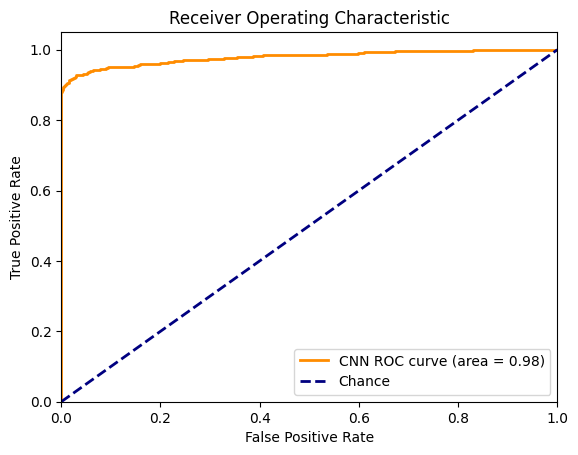

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Use predict to get probabilities for Keras models

# Use predict to get probabilities for Keras models
probs_cnn = cnn.predict(X_test)

# For binary classification, select the probability of the positive class
cnn_proba = probs_cnn[:, 1]

# Assuming y_test is in multilabel-indicator format, convert to binary format
y_test_binary = np.argmax(y_test, axis=1)  # Get the index of the true class for each sample

cnn_fpr, cnn_tpr, thresholds = roc_curve(y_test_binary,cnn_proba )
cnn_roc_auc = roc_auc_score(y_test_binary, cnn_proba)
plt.figure()

plt.plot(cnn_fpr, cnn_tpr, color='darkorange', lw=2, label='CNN ROC curve (area = %0.2f)' % cnn_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2,label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


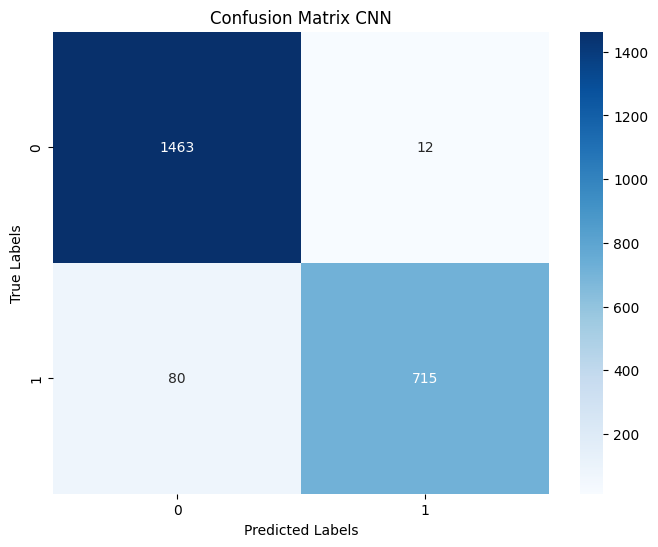

In [26]:
y_pred = np.argmax(cnn.predict(X_test), axis=1)
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix CNN')
plt.show()


In [27]:
X_train.shape

(9080, 153)

In [28]:
# Reshape input data
timestamp=1
X_train = X_train.reshape(X_train.shape[0], timestamp, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], timestamp, X_test.shape[1])

In [29]:
X_train.shape

(9080, 1, 153)

In [30]:
input_dim

153

In [31]:
timestamp=1
# Define the SimpleRNN model architecture with multiple hidden layers
rnn = Sequential()
rnn.add(SimpleRNN(128, input_shape=(timestamp,input_dim), return_sequences=True)) # First SimpleRNN layer with return_sequences=True
rnn.add(SimpleRNN(64, return_sequences=True))  # Second SimpleRNN layer with return_sequences=True
rnn.add(SimpleRNN(32, return_sequences=True))  # Third SimpleRNN layer with return_sequences=True
rnn.add(SimpleRNN(16, return_sequences=True))  # Fourth SimpleRNN layer with return_sequences=True
rnn.add(SimpleRNN(8))  # Fifth SimpleRNN layer without return_sequences=True
rnn.add(Dense(num_classes, activation='sigmoid'))
# Compile the model

# Compile the model
rnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
rnn.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - accuracy: 0.8223 - loss: 0.4026 - val_accuracy: 0.9150 - val_loss: 0.2607
Epoch 2/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9226 - loss: 0.2238 - val_accuracy: 0.9326 - val_loss: 0.1880
Epoch 3/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9332 - loss: 0.2001 - val_accuracy: 0.9075 - val_loss: 0.2164
Epoch 4/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9330 - loss: 0.1952 - val_accuracy: 0.9273 - val_loss: 0.2003
Epoch 5/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9345 - loss: 0.1913 - val_accuracy: 0.9559 - val_loss: 0.1495
Epoch 6/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9382 - loss: 0.1802 - val_accuracy: 0.9480 - val_loss: 0.1590
Epoch 7/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9431 - loss: 0.1743 - val_accuracy: 0.9590 - val_loss: 0.1477
Epoch 8/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9405 - loss: 0.1817 - val_

In [32]:
rnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 1, 128)              │          36,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 1, 64)               │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 1, 32)               │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ (None, 1, 16)               │             784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_4 (SimpleRNN)             │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 2)                   │              18 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 157,664 (615.88 KB)

 Trainable params: 52,554 (205.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 105,110 (410.59 KB)

In [33]:
# Get the predictions from the best model
y_test_pred = rnn.predict(X_test)

# Convert the predictions to binary labels
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

# Convert the true labels to binary labels
y_test_true_labels = np.argmax(y_test, axis=1)

# Calculate accuracy
test_accuracy = accuracy_score(y_test_true_labels, y_test_pred_labels)

# Calculate MCC
test_mcc = matthews_corrcoef(y_test_true_labels, y_test_pred_labels)

# Calculate specificity
test_specificity = recall_score(y_test_true_labels, y_test_pred_labels, pos_label=0)

# Calculate sensitivity
test_sensitivity = recall_score(y_test_true_labels, y_test_pred_labels, pos_label=1)
print("RNN")
print("Test Accuracy:", test_accuracy)
print("Test MCC:", test_mcc)
print("Test Specificity:", test_specificity)
print("Test Sensitivity:", test_sensitivity)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
RNN
Test Accuracy: 0.9594713656387666
Test MCC: 0.9118016828781007
Test Specificity: 0.9966101694915255
Test Sensitivity: 0.8905660377358491


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


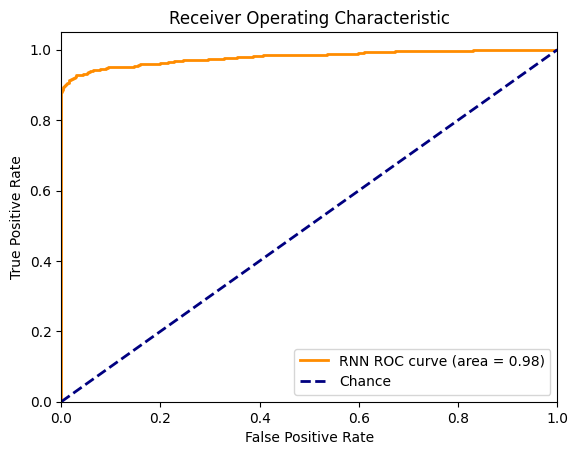

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Use predict to get probabilities for Keras models

# Use predict to get probabilities for Keras models
probs_rnn = rnn.predict(X_test)

# For binary classification, select the probability of the positive class
rnn_proba = probs_cnn[:, 1]

# Assuming y_test is in multilabel-indicator format, convert to binary format
y_test_binary = np.argmax(y_test, axis=1)  # Get the index of the true class for each sample

rnn_fpr, rnn_tpr, thresholds = roc_curve(y_test_binary,rnn_proba )
rnn_roc_auc = roc_auc_score(y_test_binary, rnn_proba)
plt.figure()

plt.plot(rnn_fpr, rnn_tpr, color='darkorange', lw=2, label='RNN ROC curve (area = %0.2f)' % rnn_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2,label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [35]:
    # Define the LSTM model architecture with multiple hidden layers
    lstm = Sequential()
    lstm.add(LSTM(128, input_shape=(timestamp,input_dim), return_sequences=True))  # First LSTM layer with return_sequences=True
    lstm.add(LSTM(64, return_sequences=True))  # Second LSTM layer with return_sequences=True
    lstm.add(LSTM(32, return_sequences=True))  # Third LSTM layer with return_sequences=True
    lstm.add(LSTM(16, return_sequences=True))  # Fourth LSTM layer with return_sequences=True
    lstm.add(LSTM(8))  # Fifth LSTM layer without return_sequences=True
    lstm.add(Dense(num_classes, activation='sigmoid'))
    # Compile the model
    lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Train the model
    lstm.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


284/284 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6943 - loss: 0.6084 - val_accuracy: 0.9159 - val_loss: 0.2553
Epoch 2/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9296 - loss: 0.2351 - val_accuracy: 0.9555 - val_loss: 0.1732
Epoch 3/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9335 - loss: 0.1965 - val_accuracy: 0.9529 - val_loss: 0.1700
Epoch 4/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9368 - loss: 0.1894 - val_accuracy: 0.9586 - val_loss: 0.1585
Epoch 5/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9428 - loss: 0.1773 - val_accuracy: 0.9392 - val_loss: 0.1712
Epoch 6/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9451 - loss: 0.1719 - val_accuracy: 0.9432 - val_loss: 0.1642
Epoch 7/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9389 - loss: 0.1876 - val_accuracy: 0.9198 - val_loss: 0.2088
Epoch 8/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9469 - loss: 0.1719 - val_accuracy: 0.

In [36]:
lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 128)              │         144,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 1, 64)               │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 1, 32)               │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 1, 16)               │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 8)                   │             800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 2)                   │              18 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 630,488 (2.41 MB)

 Trainable params: 210,162 (820.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 420,326 (1.60 MB)

In [37]:

y_test_pred = lstm.predict(X_test)

# Convert the predictions to binary labels
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

# Convert the true labels to binary labels
y_test_true_labels = np.argmax(y_test, axis=1)

# Calculate accuracy
test_accuracy = accuracy_score(y_test_true_labels, y_test_pred_labels)

# Calculate MCC
test_mcc = matthews_corrcoef(y_test_true_labels, y_test_pred_labels)

# Calculate specificity
test_specificity = recall_score(y_test_true_labels, y_test_pred_labels, pos_label=0)

# Calculate sensitivity
test_sensitivity = recall_score(y_test_true_labels, y_test_pred_labels, pos_label=1)
print("LSTM")
print("Test Accuracy:", test_accuracy)
print("Test MCC:", test_mcc)
print("Test Specificity:", test_specificity)
print("Test Sensitivity:", test_sensitivity)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
LSTM
Test Accuracy: 0.9466960352422907
Test MCC: 0.8851685001132762
Test Specificity: 1.0
Test Sensitivity: 0.8477987421383648


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


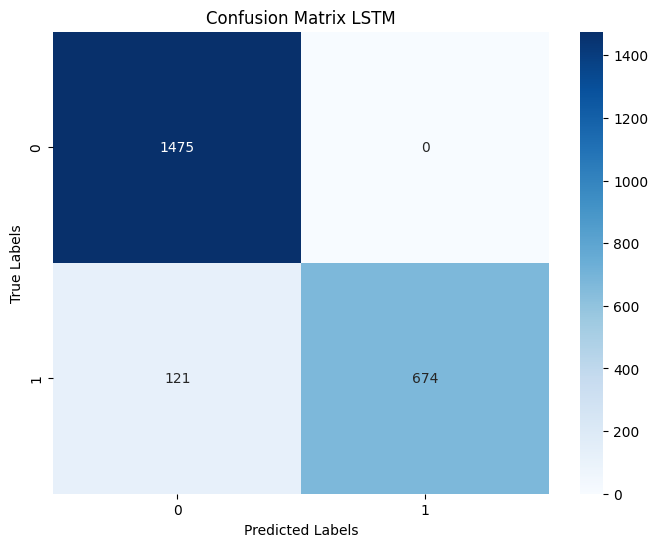

In [38]:

y_pred = np.argmax(lstm.predict(X_test), axis=1)

# Calculate confusion matrix
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix LSTM')
plt.show()


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


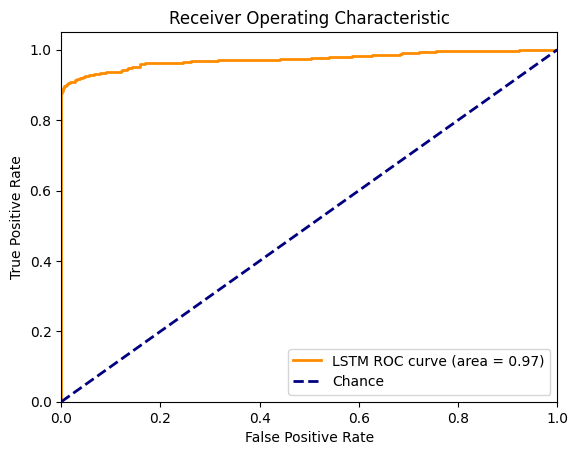

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Use predict to get probabilities for Keras models

# Use predict to get probabilities for Keras models
probs_lstm = lstm.predict(X_test)

# For binary classification, select the probability of the positive class
lstm_proba = probs_lstm[:, 1]

# Assuming y_test is in multilabel-indicator format, convert to binary format
y_test_binary = np.argmax(y_test, axis=1)  # Get the index of the true class for each sample

lstm_fpr, lstm_tpr, thresholds = roc_curve(y_test_binary,lstm_proba )
lstm_roc_auc = roc_auc_score(y_test_binary, lstm_proba)
plt.figure()

plt.plot(lstm_fpr, lstm_tpr, color='darkorange', lw=2, label='LSTM ROC curve (area = %0.2f)' % lstm_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2,label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [40]:

gru = Sequential()

# Adding the first GRU layer with 64 units and return sequences
gru.add(GRU(64, return_sequences=True, input_shape=(timestamp,input_dim)))

# Adding a dropout layer to handle overfitting
gru.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding the second GRU layer with 32 units and return sequences
gru.add(GRU(32, return_sequences=True))

# Adding a dropout layer to handle overfitting
gru.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding the third GRU layer with 16 units and no return sequences
gru.add(GRU(16))

# Adding a dropout layer to handle overfitting
gru.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding a fully connected layer with 128 neurons and ReLU activation function
gru.add(Dense(128, activation='relu'))

# Adding a dropout layer to handle overfitting
gru.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding a fully connected layer with 64 neurons and ReLU activation function
gru.add(Dense(64, activation='relu'))

# Adding a dropout layer to handle overfitting
gru.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding the output layer with appropriate activation function (e.g., softmax for classification)
gru.add(Dense(num_classes, activation='softmax'))

# Compile the model
gru.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
gru.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6665 - loss: 0.6197 - val_accuracy: 0.9498 - val_loss: 0.1994
Epoch 2/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9172 - loss: 0.2440 - val_accuracy: 0.9075 - val_loss: 0.2526
Epoch 3/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9181 - loss: 0.2507 - val_accuracy: 0.9401 - val_loss: 0.1741
Epoch 4/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9278 - loss: 0.2166 - val_accuracy: 0.9555 - val_loss: 0.1750
Epoch 5/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9274 - loss: 0.2211 - val_accuracy: 0.9414 - val_loss: 0.1782
Epoch 6/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9257 - loss: 0.2231 - val_accuracy: 0.9110 - val_loss: 0.2637
Epoch 7/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9298 - loss: 0.2265 - val_accuracy: 0.9106 - val_loss: 0.2403
Epoch 8/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9323 - loss: 0.2050 - val_ac

In [41]:
gru.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 1, 64)               │          42,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 1, 32)               │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 16)                  │           2,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 128)                 │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 193,256 (754.91 KB)

 Trainable params: 64,418 (251.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 128,838 (503.28 KB)

In [42]:

y_test_pred = gru.predict(X_test)

# Convert the predictions to binary labels
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

# Convert the true labels to binary labels
y_test_true_labels = np.argmax(y_test, axis=1)

# Calculate accuracy
test_accuracy = accuracy_score(y_test_true_labels, y_test_pred_labels)

# Calculate MCC
test_mcc = matthews_corrcoef(y_test_true_labels, y_test_pred_labels)

# Calculate specificity
test_specificity = recall_score(y_test_true_labels, y_test_pred_labels, pos_label=0)

# Calculate sensitivity
test_sensitivity = recall_score(y_test_true_labels, y_test_pred_labels, pos_label=1)
print("GRU")
print("Test Accuracy:", test_accuracy)
print("Test MCC:", test_mcc)
print("Test Specificity:", test_specificity)
print("Test Sensitivity:", test_sensitivity)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
GRU
Test Accuracy: 0.9590308370044053
Test MCC: 0.9112813148656468
Test Specificity: 0.9993220338983051
Test Sensitivity: 0.8842767295597485


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


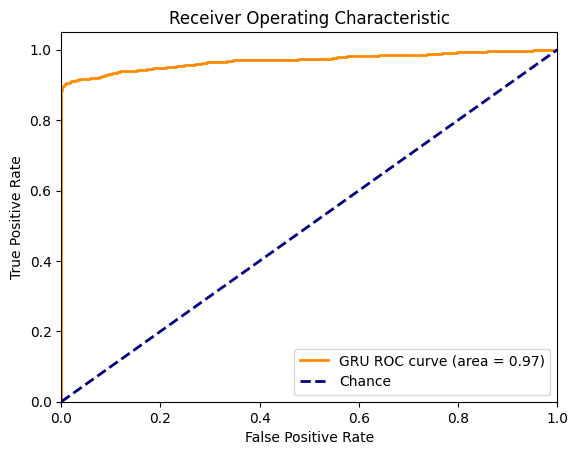

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Use predict to get probabilities for Keras models

# Use predict to get probabilities for Keras models
probs_gru = gru.predict(X_test)

# For binary classification, select the probability of the positive class
gru_proba = probs_gru[:, 1]

# Assuming y_test is in multilabel-indicator format, convert to binary format
y_test_binary = np.argmax(y_test, axis=1)  # Get the index of the true class for each sample

gru_fpr, gru_tpr, thresholds = roc_curve(y_test_binary,gru_proba )
gru_roc_auc = roc_auc_score(y_test_binary, gru_proba)
plt.figure()

plt.plot(gru_fpr, gru_tpr, color='darkorange', lw=2, label='GRU ROC curve (area = %0.2f)' % gru_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2,label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


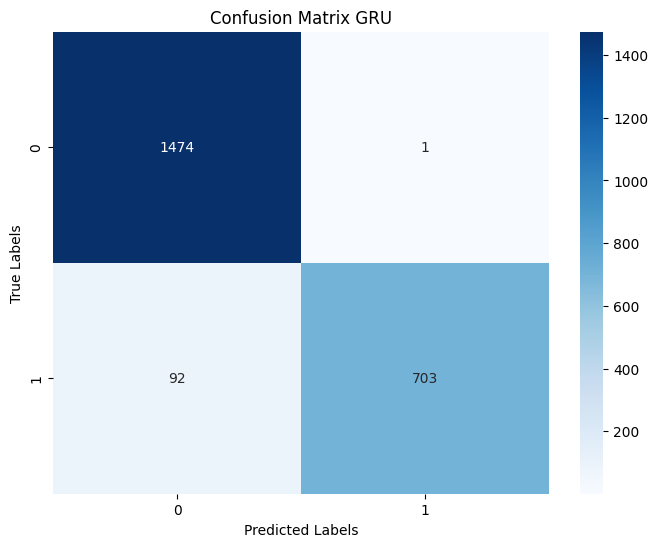

In [44]:

y_pred = np.argmax(gru.predict(X_test), axis=1)

# Calculate confusion matrix
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix GRU')
plt.show()


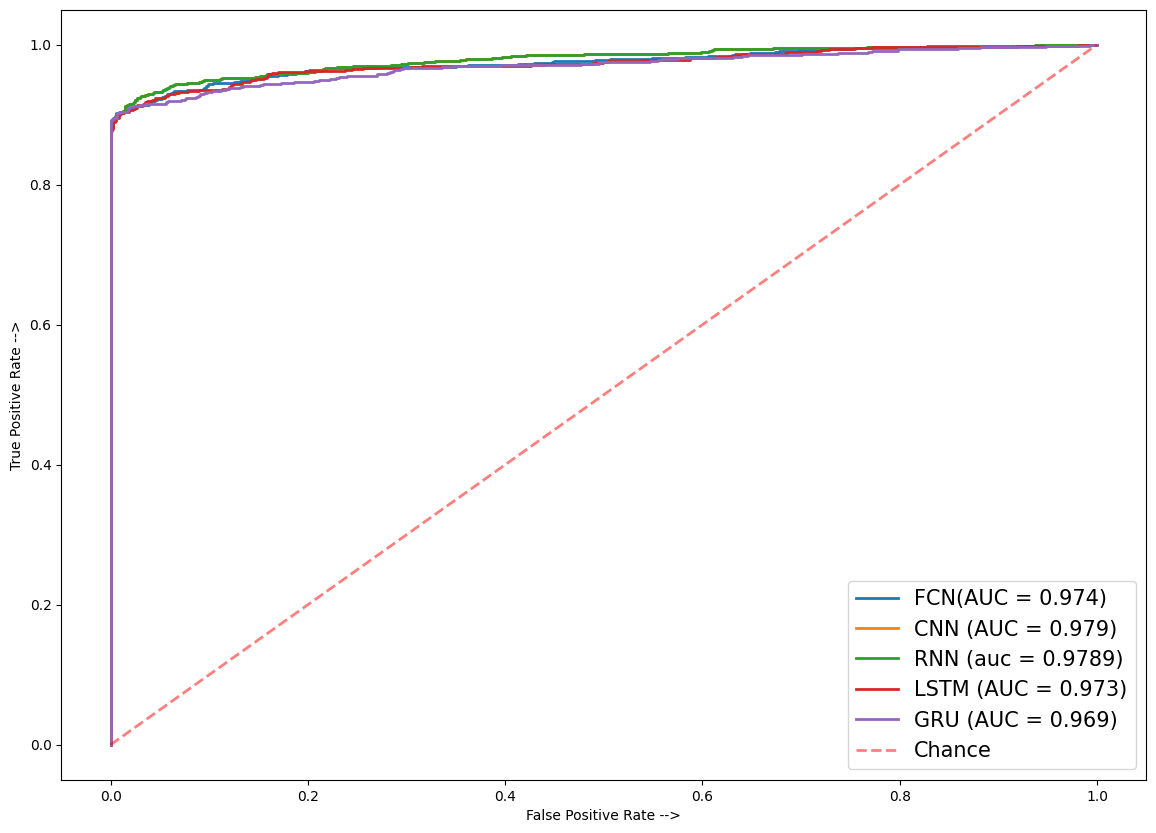

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score


plt.figure(figsize=(14,10))

#plt.plot(lstm_fpr, lstm_tpr, lw=2, label='FCN (auc = %0.4f)' % lstm_auc)
plt.plot(fcn_fpr, fcn_tpr, lw=2, label='FCN(AUC = %0.3f)' % fcn_roc_auc)
plt.plot(cnn_fpr, cnn_tpr,  lw=2, label='CNN (AUC = %0.3f)' % cnn_roc_auc)
plt.plot(rnn_fpr, rnn_tpr, lw=2, label='RNN (auc = %0.4f)' % rnn_roc_auc)
plt.plot(lstm_fpr, lstm_tpr,  lw=2, label='LSTM (AUC = %0.3f)' % lstm_roc_auc)
plt.plot(gru_fpr, gru_tpr,  lw=2, label='GRU (AUC = %0.3f)' % gru_roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.5)
#plt.plot([0, 1], [0, 1],  lw=2, color="r", label="Amino Acid Composition ROC Curve", alpha=0.8)

plt.xlabel('False Positive Rate -->')
plt.ylabel('True Positive Rate -->')

plt.legend(loc="lower right", fontsize=15, ncol=1)

plt.show()